In [81]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [82]:
import pickle
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import yaml
from io import BytesIO
from PIL import Image as PILImage
from IPython.display import display, Image as IPyImage, HTML

In [83]:
def load_prefill_buffer(prefill_path):
    with open(prefill_path, "rb") as f:
        buffer = pickle.load(f)

    print(f"Loaded {len(buffer)} transitions")

    return buffer

In [84]:
def split_buffer_into_episodes(buffer):
    episodes = []
    current_episode = []

    for i, transition in enumerate(buffer):
        current_episode.append(transition)

        done = bool(transition[-1])

        next_is_done = (i + 1 < len(buffer) and bool(buffer[i + 1][-1]))

        if done and not next_is_done:
            episodes.append(current_episode)
            current_episode = []

    print(f"Recovered {len(episodes)} episodes")

    return episodes

In [85]:
def inspect_episodes(episodes, n=5):
    lengths = [len(ep) for ep in episodes]

    print(f"Episodes: {len(episodes)}")
    print(f"Min length: {np.min(lengths)}")
    print(f"Max length: {np.max(lengths)}")
    print(f"Mean length: {np.mean(lengths):.2f}\n")

    for i in range(min(n, len(episodes))):
        print(f"Episode {i}: {len(episodes[i])} transitions")

In [86]:
def plot_episode_trajectory(episode):
    positions = []
    velocities = []
    actions = []

    for transition in episode:
        state, action, reward, next_state, done = transition

        positions.append(state[0])
        velocities.append(state[1])
        actions.append(action)

    fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

    axes[0].plot(positions)
    axes[0].set_ylabel("Position", fontsize=16)
    axes[0].grid()

    axes[1].plot(velocities)
    axes[1].set_ylabel("Velocity", fontsize=16)
    axes[1].grid()

    axes[2].step(range(len(actions)), actions, where="post")
    axes[2].set_ylabel("Action", fontsize=16)
    axes[2].set_xlabel("Step", fontsize=16)
    axes[2].grid()

    plt.tight_layout()
    plt.show()

In [87]:
def render_episode_frames(episode, env_name="MountainCar-v0"):

    env = gym.make(env_name, render_mode="rgb_array")
    env.reset()

    frames = []

    sampled_episode = episode[::1]

    for transition in sampled_episode:
        state = np.asarray(transition[0], dtype=np.float32)

        env.unwrapped.state = state.copy()
        frame = env.render()
        frames.append(frame)

    last_next_state = np.asarray(episode[-1][3], dtype=np.float32)
    env.unwrapped.state = last_next_state.copy()
    frames.append(env.render())

    env.close()

    return frames

def display_episode_gif(episode, env_name="MountainCar-v0"):
    frames = render_episode_frames(episode, env_name=env_name)

    duration_ms = int(1000 / 25)

    pil_frames = [PILImage.fromarray(frame) for frame in frames]

    buffer = BytesIO()

    pil_frames[0].save(buffer, format="GIF", save_all=True,
        append_images=pil_frames[1:], duration=duration_ms, loop=0)

    display(IPyImage(data=buffer.getvalue(), width=500))

In [88]:
with open("../config/agent_dqn_config.yaml", "r") as f:
    config = yaml.safe_load(f)

Loaded 7624 transitions
Recovered 50 episodes
Episodes: 50
Min length: 109
Max length: 194
Mean length: 152.48

Episode 0: 155 transitions
Episode 1: 152 transitions
Episode 2: 155 transitions
Episode 3: 161 transitions
Episode 4: 161 transitions


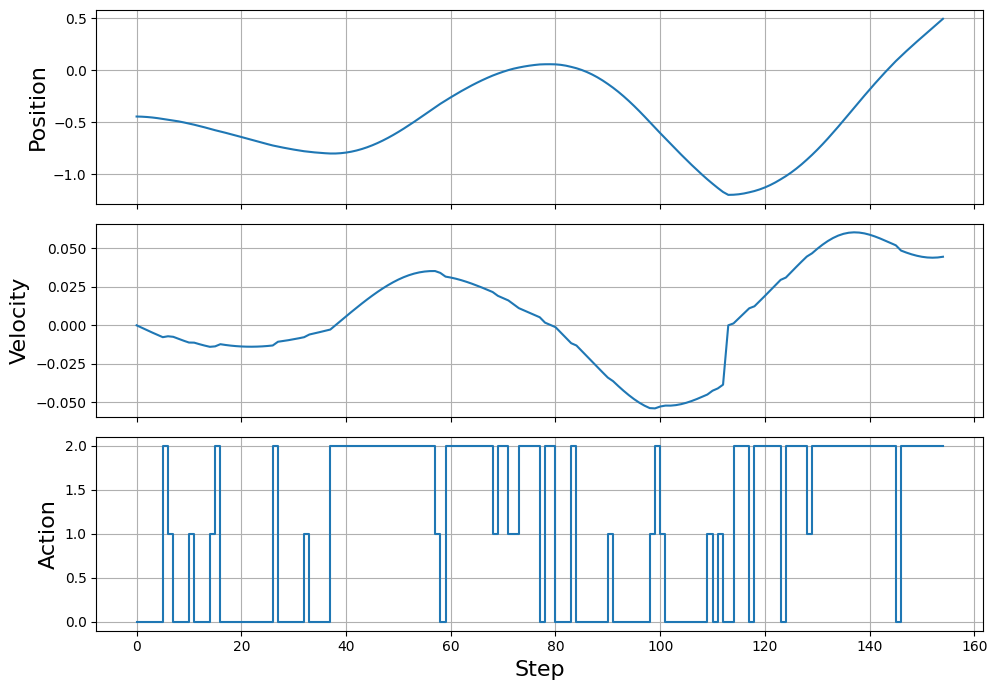

Mean episode length: 152.48 | Std: 14.71


In [89]:
experiment_folder = "mountaincar"
params = config[experiment_folder]

prefill_episodes = params["prefill_episodes"]
prefill_epsilon = params["prefill_epsilon"]

prefill_path = (
    f"../prefill_buffers/agent_dqn/"
    f"{experiment_folder}/"
    f"buffer_{prefill_episodes}_eps_{prefill_epsilon}.pkl"
)

buffer = load_prefill_buffer(prefill_path)
episodes = split_buffer_into_episodes(buffer)
inspect_episodes(episodes, n=5)
plot_episode_trajectory(episodes[0])

mean_reward = np.mean([len(ep) for ep in episodes])
std = np.std([len(ep) for ep in episodes])
print(f"Mean episode length: {mean_reward:.2f} | Std: {std:.2f}")

# for i, ep in enumerate(episodes[:5]):
#     display(HTML(f"<h3>Episode {i} | length = {len(ep)}</h3>"))
#     display_episode_gif(ep)

In [90]:
from stable_baselines3 import DQN
from huggingface_sb3 import load_from_hub

checkpoint = load_from_hub(
    repo_id="sb3/dqn-MountainCar-v0",
    filename="dqn-MountainCar-v0.zip",
)


In [103]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt


def generate_expert_episode(
    expert_model,
    env_name="MountainCar-v0",
    seed=0,
    deterministic=True,
    max_steps=200,
    reward_shaping_fn=None,
    plot=True,
):
    """
    Genera 1 episodio usando un modelo experto de Stable-Baselines3.

    No guarda nada en disco.

    Retorna:
        episode: lista de transiciones con formato:
            (state, action, reward, next_state, done)
    """

    env = gym.make(env_name, render_mode=None)

    state, _ = env.reset(seed=seed)

    episode = []
    terminated = False
    truncated = False

    total_reward = 0.0

    for step in range(max_steps):

        if np.random.rand() < 0.05:
            action = env.action_space.sample()
        else:
            action, _ = expert_model.predict(
                state,
                deterministic=deterministic
            )


        action = int(np.asarray(action).item())

        next_state, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        done = terminated or truncated

        if reward_shaping_fn is not None:
            reward_to_store = reward_shaping_fn(
                next_state,
                reward,
                terminated
            )
        else:
            reward_to_store = reward

        episode.append(
            (
                np.asarray(state, dtype=np.float32).copy(),
                action,
                float(reward_to_store),
                np.asarray(next_state, dtype=np.float32).copy(),
                done,
            )
        )

        state = next_state

        if done:
            break

    env.close()

    if plot:
        plot_episode_position_velocity_actions(episode)

    return episode

def plot_episode_position_velocity_actions(episode):
    """
    Grafica posición, velocidad y acciones elegidas para un episodio.
    """

    states = np.array([transition[0] for transition in episode])
    next_states = np.array([transition[3] for transition in episode])
    actions = np.array([transition[1] for transition in episode])

    positions = np.concatenate([states[:, 0], [next_states[-1, 0]]])
    velocities = np.concatenate([states[:, 1], [next_states[-1, 1]]])

    steps_states = np.arange(len(positions))
    steps_actions = np.arange(len(actions))

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)

    axes[0].plot(steps_states, positions)
    axes[0].axhline(0.5, linestyle="--", linewidth=1, label="Goal position")
    axes[0].set_ylabel("Position", fontsize=16)
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(steps_states, velocities)
    axes[1].set_ylabel("Velocity", fontsize=16)
    axes[1].grid(True)

    axes[2].step(steps_actions, actions, where="post")
    axes[2].scatter(steps_actions, actions, s=18)
    axes[2].set_yticks([0, 1, 2])
    axes[2].set_yticklabels(["Left (0)", "Neutral (1)", "Right (2)"])
    axes[2].set_ylabel("Action", fontsize=16)
    axes[2].set_xlabel("Step", fontsize=16)
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

c:\Users\Lucio\miniconda3\envs\RL\Lib\site-packages\stable_baselines3\common\save_util.py:167: UserWarning: Could not deserialize object learning_rate. Consider using `custom_objects` argument to replace this object.
Exception: code expected at least 16 arguments, got 15
  warnings.warn(
c:\Users\Lucio\miniconda3\envs\RL\Lib\site-packages\stable_baselines3\common\save_util.py:167: UserWarning: Could not deserialize object lr_schedule. Consider using `custom_objects` argument to replace this object.
Exception: code expected at least 16 arguments, got 15
  warnings.warn(
c:\Users\Lucio\miniconda3\envs\RL\Lib\site-packages\stable_baselines3\common\save_util.py:167: UserWarning: Could not deserialize object exploration_schedule. Consider using `custom_objects` argument to replace this object.
Exception: code expected at least 16 arguments, got 15
  warnings.warn(
c:\Users\Lucio\miniconda3\envs\RL\Lib\site-packages\stable_baselines3\common\base_class.py:773: UserWarning: You are probably lo

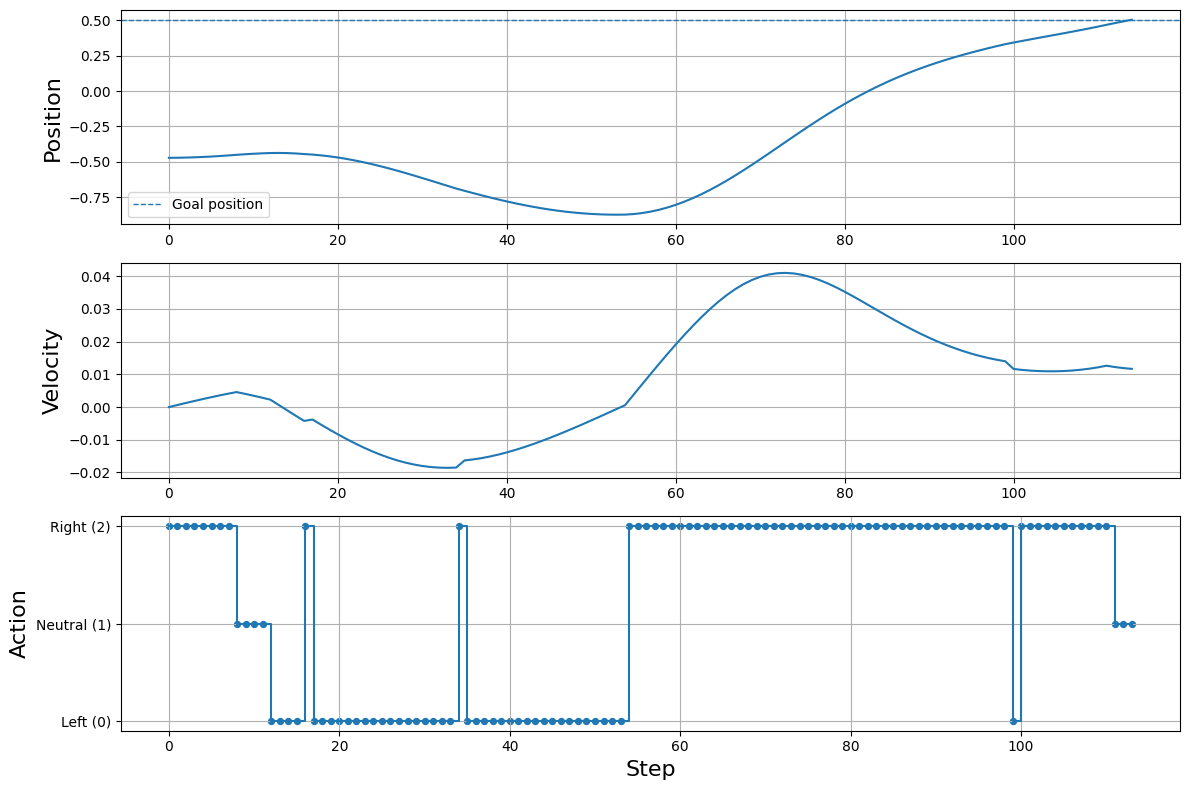

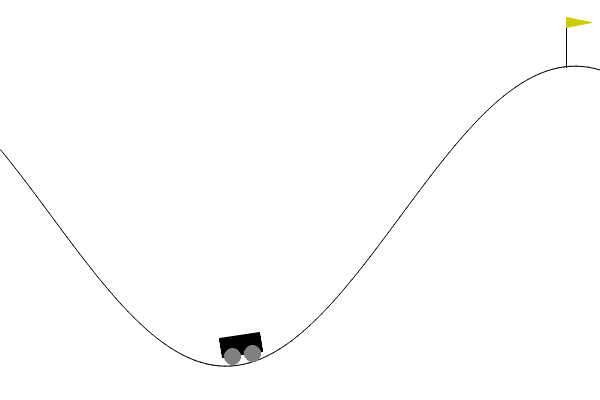

Average reward over 100 episodes: -126.39 +- 33.52


In [104]:
checkpoint = load_from_hub(
    repo_id="sb3/dqn-MountainCar-v0",
    filename="dqn-MountainCar-v0.zip",
)

custom_objects = {
    "observation_space": gym.spaces.Box(
        low=np.array([-1.2, -0.07], dtype=np.float32),
        high=np.array([0.6, 0.07], dtype=np.float32),
        dtype=np.float32,
    ),
    "action_space": gym.spaces.Discrete(3),
}

expert_model = DQN.load(
    checkpoint,
    device="cpu",
    custom_objects=custom_objects,
)

episode = generate_expert_episode(
    expert_model=expert_model,
    env_name="MountainCar-v0",
    seed=0,
    deterministic=True,
    reward_shaping_fn=None,
    plot=True,
)

display_episode_gif(episode)

episodes = 100

rewards = []
for i in range(episodes):
    episode = generate_expert_episode(expert_model=expert_model,
    env_name="MountainCar-v0",
    seed=0,
    deterministic=True,
    reward_shaping_fn=None,
    plot=False,
    )
    rewards.append(-1*len(episode))

print(f"Average reward over {episodes} episodes: {np.mean(rewards):.2f} +- {np.std(rewards):.2f}")




c:\Users\Lucio\miniconda3\envs\RL\Lib\site-packages\stable_baselines3\common\save_util.py:167: UserWarning: Could not deserialize object learning_rate. Consider using `custom_objects` argument to replace this object.
Exception: code expected at least 16 arguments, got 15
  warnings.warn(
c:\Users\Lucio\miniconda3\envs\RL\Lib\site-packages\stable_baselines3\common\save_util.py:167: UserWarning: Could not deserialize object lr_schedule. Consider using `custom_objects` argument to replace this object.
Exception: code expected at least 16 arguments, got 15
  warnings.warn(
c:\Users\Lucio\miniconda3\envs\RL\Lib\site-packages\stable_baselines3\common\save_util.py:167: UserWarning: Could not deserialize object clip_range. Consider using `custom_objects` argument to replace this object.
Exception: code expected at least 16 arguments, got 15
  warnings.warn(


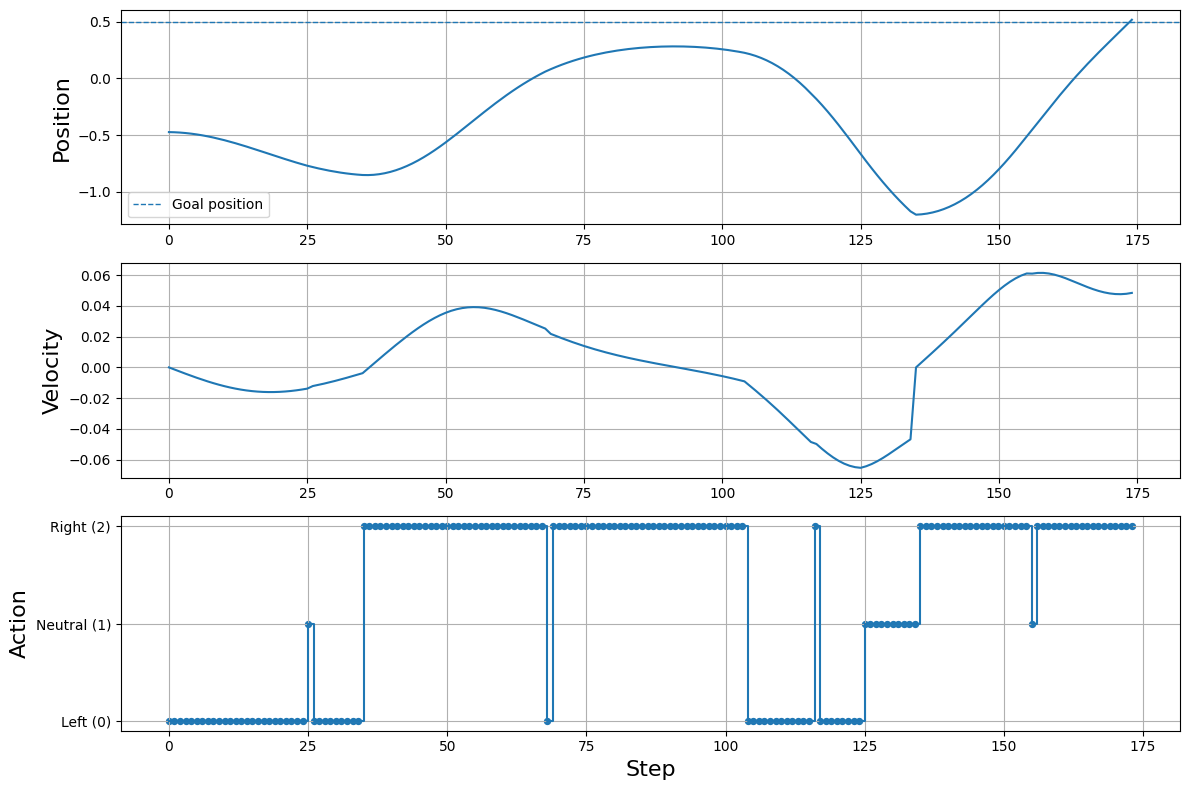

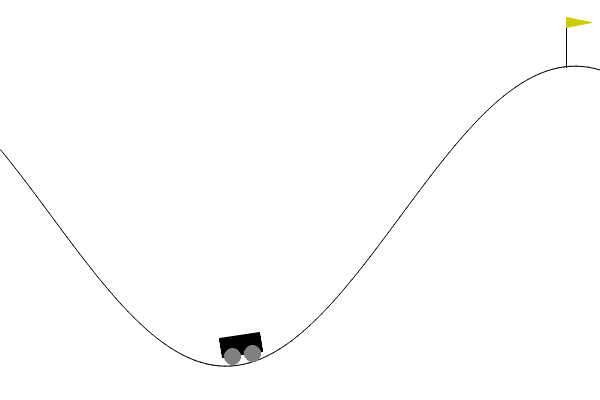

Average reward over 100 episodes: -162.51 +- 23.29


In [105]:
from huggingface_sb3 import load_from_hub
from stable_baselines3 import PPO

repo_id = "vukpetar/ppo-MountainCar-v0"
filename = "ppo-mountaincar-v0.zip"

checkpoint = load_from_hub(
    repo_id=repo_id,
    filename=filename,
)

expert_model = PPO.load(
    checkpoint,
    device="cpu",
    custom_objects=custom_objects,
)

episode = generate_expert_episode(
    expert_model=expert_model,
    env_name="MountainCar-v0",
    seed=0,
    deterministic=True,
    reward_shaping_fn=None,
    plot=True,
)

display_episode_gif(episode)

episodes = 100

rewards = []
for i in range(episodes):
    episode = generate_expert_episode(expert_model=expert_model,
    env_name="MountainCar-v0",
    seed=0,
    deterministic=True,
    reward_shaping_fn=None,
    plot=False,
    )
    rewards.append(-1*len(episode))

print(f"Average reward over {episodes} episodes: {np.mean(rewards):.2f} +- {np.std(rewards):.2f}")


